# Does Beijing's easing button actually push stocks up? 🇨🇳
### The PBoC "stimulus rally" — a headline you've read fifty times, tested against the tape

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Buy_the_rumor%2C_sell_the_news%3F: Busted](https://img.shields.io/badge/Buy_the_rumor%2C_sell_the_news%3F-Busted-8b949e?style=flat-square)

Every few months the People's Bank of China cuts the **Reserve Requirement Ratio (RRR)** — the share of deposits banks must lock away instead of lending out — and the financial press runs some version of the same headline: *"China stocks rally as PBoC cuts reserve ratio."* It sounds like plain economics: freeing up lending capacity is stimulus, stimulus is bullish, so equities should pop.

That's the claim we test — and, quietly, its unstated mirror: if a cut is bullish, a **hike** should be bearish. Steelmanning a folk claim means testing *both* halves, not just the flattering one.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 48 hardcoded, BROAD-BASED PBoC RRR announcements (2008 → 2025: 31 cuts, 17 hikes) — targeted relief for rural/SME lenders is excluded, because that's not the "big lever" the folklore is about. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from pboc_rrr_effect import data, strategy as st

RRR = data.rrr_frame()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    FXI, MCHI = data.load_real()
    MATCHED_FXI = st.match_trading_days(FXI.index, RRR)
    MATCHED_MCHI = st.match_trading_days(MCHI.index, RRR)
    DF = st.day_frame(FXI, MATCHED_FXI)
    MDF = st.day_frame(MCHI, MATCHED_MCHI)
    CUT_DAYS = pd.DatetimeIndex(MATCHED_FXI.loc[MATCHED_FXI["direction"] == "cut", "trading_date"])
else:
    FXI = MCHI = DF = MDF = MATCHED_FXI = CUT_DAYS = None
print("real cache present:", HAVE_REAL, "| RRR announcements:", len(RRR),
      "| tape days:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2008-01-01', 'end': '2026-06-30', 'n_events': 48, 'n_cut': 31, 'n_hike': 17, 'cal_lo': '2008-01-16', 'cal_hi': '2025-05-07', 'cut_pct': 0.7145, 'cut_rest_pct': -0.0079, 'cut_gap': 0.7225, 'cut_t': 0.99, 'cut_nw': 1.0, 'cut_hit': 20, 'cut_n': 31, 'cut_hit_pct': 64.5, 'cut_wilson': (46.9, 78.9), 'hike_pct': 0.6397, 'hike_rest_pct': -0.0055, 'hike_gap': 0.6452, 'hike_t': 1.36, 'hike_nw': 1.4, 'hike_hit': 13, 'hike_n': 17, 'hike_hit_pct': 76.5, 'hike_wilson': (52.7, 90.4), 'cvh_t': 0.09, 'placebo_cut_p': 0.0296, 'placebo_cut_mean': -0.0057, 'placebo_cut_sd': 0.3682, 'placebo_hike_p': 0.9132, 'placebo_hike_mean': -0.009, 'placebo_hike_sd': 0.4953, 'event': {-5: (-0.184, -0.36), -4: (-0.7631, -1.3), -3: (0.366, 0.64), -2: (0.0092, 0.0), -1: (-0.6345, -1.08), 0: (0.7145, 0.96), 1: (0.4567, 0.77), 2: (-0.5126, -0.76), 3: (1.0035, 1.58), 4: (-0.5204, -1.06), 5: (-0.4434, -0.88), 6: (-0.3196, -0.85), 7: (-0.613, -0.84), 8: (-0.6753, -1.32), 9: (1.3584, 1.87), 10: (-0.7219, -1.97)}, 'runup_pct': -1.206, 'runup_t': -0.97, 'runup_n': 31, 'post_pct': -0.943, 'post_t': -0.71, 'post_n': 31, 'range_event': 2.1772, 'range_rest': 1.49, 'range_t': 2.45, 'mchi_cut_n': 27, 'mchi_cut_pct': 0.9768, 'mchi_cut_rest': 0.0008, 'mchi_cut_t': 1.98, 'mchi_hike_n': 3, 'mchi_hike_pct': 0.9219, 'mchi_hike_rest': 0.0069, 'mchi_hike_t': 2.59, 'mchi_cvh_t': 0.09, 'era_early_pct': -0.3898, 'era_early_n': 7, 'era_early_t': -0.13, 'era_late_pct': 1.0366, 'era_late_n': 24, 'era_late_t': 2.1, 'era_diff_t': 0.49, 'timer': {1: (71.5, 61.5, 1.7, 0.95, 64.5, -16.1), 3: (65.9, 55.9, 7.3, 0.57, 61.3, -15.9), 5: (111.8, 101.8, 14.3, 0.87, 54.8, -15.9), 10: (30.1, 20.1, 30.4, -0.0, 58.1, -29.8)}, 'syn_null_mean': -0.15, 'syn_null_sd': 1.22, 'syn_null_fire': 2, 'syn_planted_t': 4.13, 'fp_fxi': 'd41690523582', 'fp_mchi': '460c227db0e1'}


real cache present: True | RRR announcements: 48 | tape days: 4651


## The answer first

| Question | Answer |
|---|---|
| Do Chinese equities pop on a cut day? | **On paper, yes** — FXI averages **+0.71%** on a cut day vs about zero normally. But that number alone can't tell you why. |
| Do they fall on a HIKE day, as the same logic would predict? | **No — they ALSO pop**, by almost exactly the same amount (**+0.64%**). That's the tell. |
| So does direction matter at all? | **No.** Cuts vs hikes, head to head: statistically indistinguishable (Welch *t* = 0.09 — the bar for "real" is 2). Whatever makes RRR announcement days run hot, it isn't the direction of the move. |
| Can you at least trade the timing — buy the rumor, sell the news? | **No.** The days *before* a cut actually drift slightly DOWN (-1.21%, not up), and a 10-day hold after the cut earns exactly what a random 10-day window earns. |

> A headline you've read fifty times, and the tape says: not because of the direction.

## 1 · The claim

> *"The PBoC cutting the RRR frees up bank lending capacity across the whole system — that's stimulus, stimulus is bullish, and Chinese equities should rally on the news."*

It's intuitive, it's repeated after nearly every cut by Reuters, Bloomberg and CNBC, and it has a real economic mechanism behind it (more lendable reserves *can* support credit growth). What it rarely gets is the honest mirror-image test: if cuts are bullish stimulus, hikes should be bearish tightening. We test both.

## 2 · So what?

If real, this is about as simple an edge as macro trading gets: watch one official's calendar, buy the ETF on the announcement, collect the pop. China watchers already try to front-run State Council hints of an upcoming cut. If it doesn't hold up, that's worth knowing too — it means the "stimulus rally" headline you keep reading is describing a coincidence, not a mechanism you can set a calendar alert for.

## 3 · How would we even know?

- **The calendar.** All **48** broad-based PBoC RRR announcements 2008-01-16 → 2025-05-07 (31 cuts, 17 hikes), hardcoded from the PBoC's own announcement archive.
- **The comparison.** FXI's (China large-cap ETF) return on each announcement's trading day vs every other day — split separately for cuts and for hikes.
- **The decisive test.** Cuts vs hikes, head to head. If direction matters, this gap should be large; if the folklore is really just "RRR days are eventful days," this gap should be near zero.
- **The trade check.** Buy FXI at the close before a cut, hold 1/3/5/10 trading days, pay costs — does any horizon actually pay?

## 4 · The teardown — let's actually look

**First, the headline split** — cut days and hike days, each against an ordinary trading day.

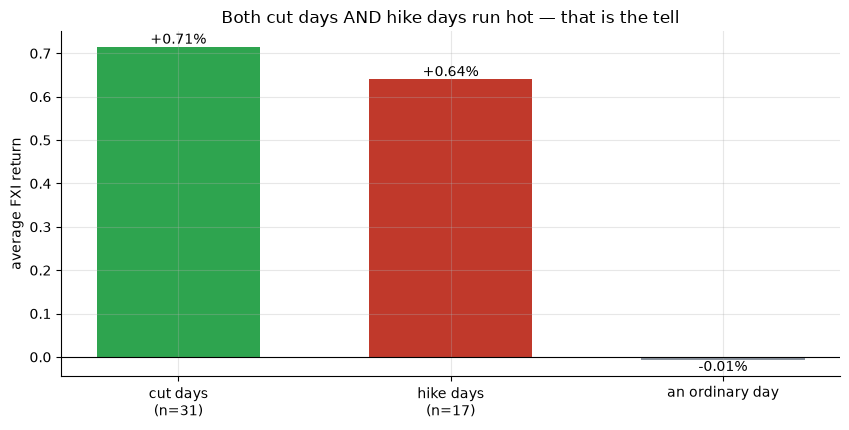

cut +0.715%   hike +0.640%   ordinary day -0.008%


In [2]:
if HAVE_REAL:
    sc = st.decision_day_stats(DF, 'ret', 'cut')
    sh = st.decision_day_stats(DF, 'ret', 'hike')
    cp, hp, rp = sc['event_pct'], sh['event_pct'], sc['rest_pct']
else:
    cp, hp, rp = R['cut_pct'], R['hike_pct'], R['cut_rest_pct']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(['cut days\n(n=31)', 'hike days\n(n=17)', 'an ordinary day'],
       [cp, hp, rp], color=[GREEN, RED, GREY], width=.6)
for i, v in enumerate([cp, hp, rp]):
    ax.annotate(f'{v:+.2f}%', (i, v), ha='center', va='bottom' if v >= 0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('average FXI return')
ax.set_title('Both cut days AND hike days run hot — that is the tell')
plt.tight_layout(); plt.show()
print(f'cut {cp:+.3f}%   hike {hp:+.3f}%   ordinary day {rp:+.3f}%')

Cut days average **+0.71%**. That alone looks like the folklore, until you check the mirror: hike days average **+0.64%** — nearly identical, and in the SAME direction a tightening move is supposed to oppose. Both kinds of RRR day run far hotter than an ordinary day (-0.01%), but not because of what the RRR did.

**The decisive number** makes this precise: cuts vs hikes, directly.

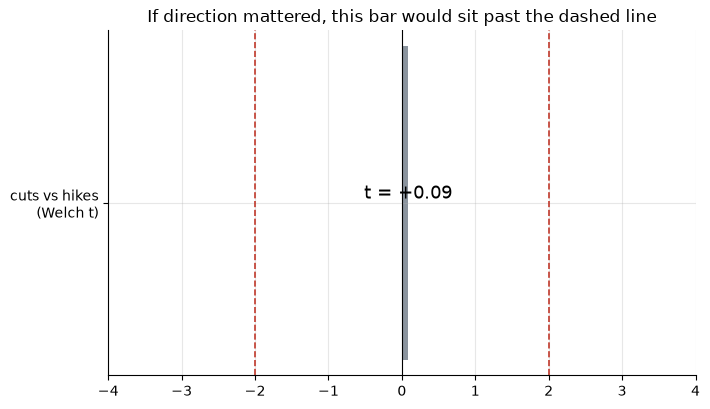

cuts vs hikes, Welch t = +0.09  (bar for "real" is 2)


In [3]:
if HAVE_REAL:
    cvh = st.cuts_vs_hikes(DF, 'ret')
    t = cvh['welch_t']
else:
    t = R['cvh_t']
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.barh(['cuts vs hikes\n(Welch t)'], [t], color=GREY, height=.5)
ax.axvline(0, c='k', lw=.8)
ax.axvline(2, ls='--', c=RED, lw=1.2); ax.axvline(-2, ls='--', c=RED, lw=1.2)
ax.annotate(f't = {t:+.2f}', (t, 0), ha='center', va='bottom', fontsize=13)
ax.set_xlim(-4, 4)
ax.set_title('If direction mattered, this bar would sit past the dashed line')
plt.tight_layout(); plt.show()
print(f'cuts vs hikes, Welch t = {t:+.2f}  (bar for "real" is 2)')

**Welch *t* = 0.09.** The bar for calling something real on this desk is *t* = 2 — and this is about as close to a coin flip as a statistic gets. Cut days and hike days are not distinguishable from each other. Whatever makes RRR announcement days run hot — and the market IS louder on those days, not just higher — it isn't the direction of the move.

**So what does drift around the announcement look like?**

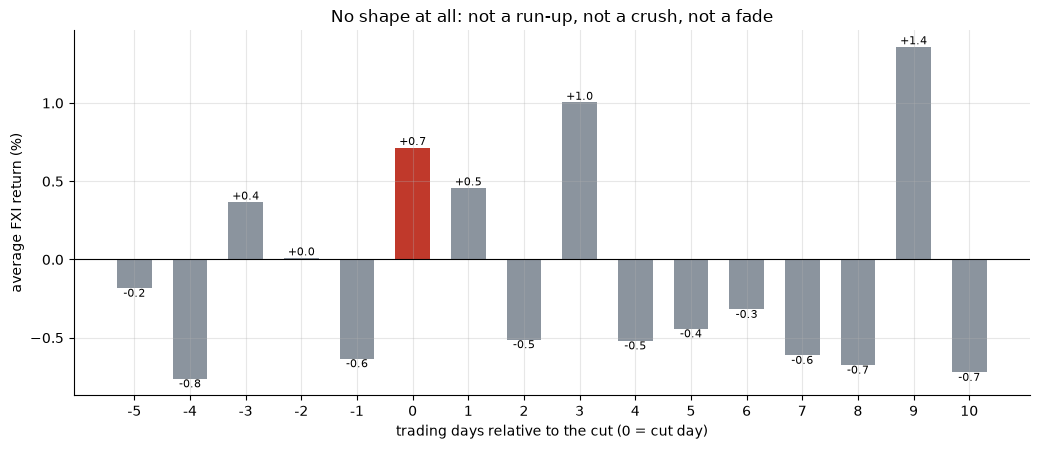

offsets: {-5: -0.18, -4: -0.76, -3: 0.37, -2: 0.01, -1: -0.63, 0: 0.71, 1: 0.46, 2: -0.51, 3: 1.0, 4: -0.52, 5: -0.44, 6: -0.32, 7: -0.61, 8: -0.68, 9: 1.36, 10: -0.72}


In [4]:
if HAVE_REAL:
    ev = st.event_study(DF, 'ret', CUT_DAYS)
    ks, ms = list(ev.index), list(ev['mean_pct'])
else:
    ks = sorted(R['event']); ms = [R['event'][k][0] for k in ks]
fig, ax = plt.subplots(figsize=(10.5, 4.6))
cols = [RED if k == 0 else GREY for k in ks]
ax.bar([str(k) for k in ks], ms, color=cols, width=.62)
for i, v in enumerate(ms):
    ax.annotate(f'{v:+.1f}', (i, v), ha='center',
                va='bottom' if v >= 0 else 'top', fontsize=8)
ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('trading days relative to the cut (0 = cut day)')
ax.set_ylabel('average FXI return (%)')
ax.set_title('No shape at all: not a run-up, not a crush, not a fade')
plt.tight_layout(); plt.show()
print('offsets:', {k: round(m, 2) for k, m in zip(ks, ms)})

There's no recognizable pattern here — no ramp into the cut, no clean pop that fades afterward. The five days BEFORE a cut actually drift down a little (**-1.21%** cumulative, not up — so much for "buying the rumor"), and the ten days after are flat-to-slightly-negative on average. **Finally, the trade:** does any holding period actually pay, after costs?

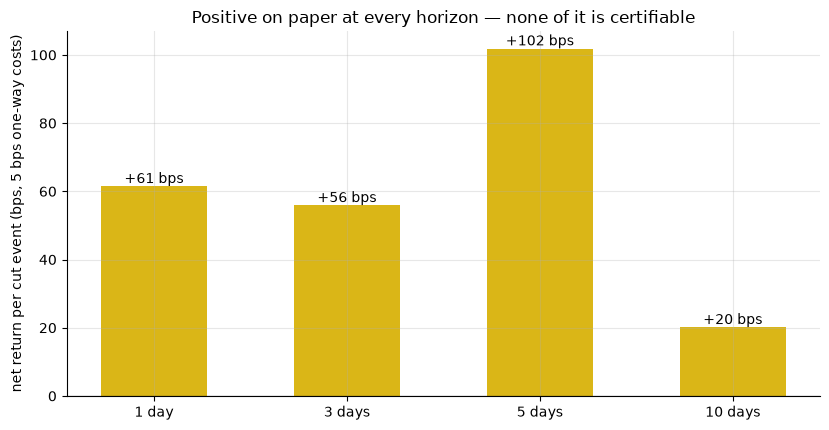

net bps by hold: {1: 61.5, 3: 55.9, 5: 101.8, 10: 20.1}


In [5]:
if HAVE_REAL:
    caps = [st.capture_horizon(FXI['AdjClose'], MATCHED_FXI, 'cut', h, 5.0)
            for h in (1, 3, 5, 10)]
    nets = [c['net_bps'] for c in caps]
else:
    nets = [R['timer'][h][1] for h in (1, 3, 5, 10)]
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['1 day', '3 days', '5 days', '10 days'], nets, color=AMBER, width=.55)
for i, v in enumerate(nets):
    ax.annotate(f'{v:+.0f} bps', (i, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('net return per cut event (bps, 5 bps one-way costs)')
ax.set_title('Positive on paper at every horizon — none of it is certifiable')
plt.tight_layout(); plt.show()
print('net bps by hold:', {h: round(n, 1) for h, n in zip((1, 3, 5, 10), nets)})

Every bar is positive — and every single one sits at a Welch *t* well under 2 (the best is 0.95). The 10-day hold, the horizon closest to "did the pop hold up after the news cycle moved on," earns **exactly what a random 10-day window on the same tape earns** — zero excess. Add a worst-case single event of **-29.8%** over that horizon, and there's nothing here to bank.

## 5 · The verdict

- **Signal — None.** Cut days and hike days are statistically indistinguishable (Welch *t* = 0.09, confirmed on a second, independently constructed China ETF). RRR announcement days ARE louder than average — the market moves more on those days — but not in a direction the folklore predicts.
- **Tradability — Mirage.** No holding period of a buy-the-cut timer clears the bar; the longest horizon shows zero excess over random chance.
- **"Buy the rumor, sell the news"? — Busted.** There's no rumor phase (prices drift down before a cut, not up) and no clean news-selloff either. The story just isn't in the data.

## 6 · Going further 🚪

- **What might actually be going on:** RRR cuts don't arrive at random — they cluster in stretches when Beijing is already leaning supportive (property-market stress, growth wobbles, coordinated "national team" buying). The loud-but-directionless pattern here is consistent with RRR days being *correlated with* supportive periods, not *causing* them.
- **The professional angle:** if there's a real edge in Chinese monetary policy for equities, it more plausibly lives in policy-RATE surprises (the 1yr/5yr LPR) or in reading State-Council pre-announcements days ahead — not in the RRR announcement itself, which this study finds carries no average directional content.
- **Sibling studies:** [620-a-h-premium](../../620-a-h-premium/) (the structural A/H price gap, no calendar) and [313-geopolitical-shock](../../313-geopolitical-shock/) (the same event-study skeleton, a completely different market) — neither overlaps this study's claim.

*Think the edge is real but mistimed? Show a net, certifiable directional gap between cuts and hikes — after costs, on out-of-sample announcements — then we'll talk.*